# Parity-Net Colab Runner
This notebook clones the GitHub repo, trains the mean-field-style residual network from `MOTIVATION.md`, saves checkpoints to Google Drive, and runs PCA rank-reduction analysis.
Before running, set `GITHUB_REPO_URL` to the URL of your pushed repo.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
GITHUB_REPO_URL = "https://github.com/labofdoubt/feature-learning-parity-task.git"
REPO_DIR = "/content/feature-learning-parity-task"

!rm -rf "$REPO_DIR"
!git clone "$GITHUB_REPO_URL"
%cd "$REPO_DIR"
!pip install -e .


Cloning into 'feature-learning-parity-task'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 84 (delta 44), reused 73 (delta 33), pack-reused 0 (from 0)
Receiving objects: 100% (84/84), 534.52 KiB | 2.66 MiB/s, done.
Resolving deltas: 100% (44/44), done.
/content/feature-learning-parity-task
Obtaining file:///content/feature-learning-parity-task
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for parity-net (pyproject.toml) ... done
  Created wheel for parity-net: filename=parity_net-0.1.0-0.editable-py3-none-any.whl size=3070 sha256=aba499cf3635e437df1ccf6c1381e60d26b2d4bb70700c73788efe0688ade433
  Stored in directory: /tmp/pip-ephem-wheel-cache-80u6xs99/wheels/a2/05/6b/5da726f55833c1e289bd27eaf6964cb7ead0a8

In [32]:
DRIVE_RUN_DIR = "/content/drive/MyDrive/ml_projects_new/parity_runs/example_run_2"

## Create Configs
`barrier_c` is in the training config because it enters as a loss regularizer. If left as `None`, the training code uses `7 / N`.



In [ ]:
from pathlib import Path
import yaml

N = 256

config = {
    "model": {
        "input_dim": 32,
        "relevant_dim": 16,
        "N": N,
        "L": 3,
        "activation": "relu",
        "use_readout_barrier": False,
        "embedding_weight_variance": 1.0/32,
        "hidden_weight_variance": 1.0/N,
        "readout_weight_variance": 1.0/N,
        "use_post_activation_linear": False,
        "bias": False,
    },
    "training": {
        "num_steps": 100_000,
        "test_samples": 100_000,
        "batch_size": 512,
        "seed": 0,
        "device": "cuda",
        "dtype": "float32",
        "log_every": 1_000,
        "checkpoint_every": 1_000,
        "output_dir": DRIVE_RUN_DIR,
        "barrier_c": None,
        "barrier_lambda": 10.0,
        "optimizer": {
            "name": "sgd",
            "lr": 1e-2,
            "weight_decay": 0.0,
            "momentum": 0.9,
            "betas": [0.9, 0.999],
        },
    },
}
config_path = Path(DRIVE_RUN_DIR) / "config.yaml"
config_path.parent.mkdir(parents=True, exist_ok=True)
with config_path.open("w") as f:
    yaml.safe_dump(config, f, sort_keys=False)
config_path


PosixPath('/content/drive/MyDrive/ml_projects_new/parity_runs/example_run_2/config.yaml')

## Train

Training samples a fresh random batch at every optimizer step. `num_steps` is the number of weight updates.
This runs the repo command and saves intermediate checkpoints to Google Drive.



In [34]:
!parity-train --config "$config_path"

{'step': 1000, 'elapsed_seconds': 3.6436009700000795, 'train_mse': 0.2531929016113281, 'barrier': 0.0, 'loss': 0.2531929016113281, 'test_mse': 0.2538112998008728, 'test_mse_d2': 0.033153314143419266, 'test_mse_d4': 0.12764285504817963, 'test_mse_d8': 1.0105458498001099, 'test_mse_d16': 1.0102800130844116}
{'step': 2000, 'elapsed_seconds': 7.395723099999941, 'train_mse': 0.21430183947086334, 'barrier': 0.0, 'loss': 0.21430183947086334, 'test_mse': 0.21705085039138794, 'test_mse_d2': 0.014536555856466293, 'test_mse_d4': 0.02825196646153927, 'test_mse_d8': 1.0061709880828857, 'test_mse_d16': 1.0141202211380005}
{'step': 3000, 'elapsed_seconds': 10.636173278000115, 'train_mse': 0.20967698097229004, 'barrier': 0.0, 'loss': 0.20967698097229004, 'test_mse': 0.20940464735031128, 'test_mse_d2': 0.009428555145859718, 'test_mse_d4': 0.017586126923561096, 'test_mse_d8': 0.9924476146697998, 'test_mse_d16': 1.0104013681411743}
{'step': 4000, 'elapsed_seconds': 13.972550961999787, 'train_mse': 0.1845

## Load Checkpoint and Inspect Weight Variance



In [ ]:
import torch
import pandas as pd
from parity_net.checkpoint import load_checkpoint
from parity_net.data import ParityDataset, load_dataset
from parity_net.train import resolve_device, resolve_dtype

checkpoint_path = Path(DRIVE_RUN_DIR) / "checkpoints" / "step_00100000.pt"
device = resolve_device(config["training"]["device"])
dtype = resolve_dtype(config["training"]["dtype"])
model, payload, _ = load_checkpoint(checkpoint_path, device)

saved_output_dir = Path(payload["config"]["training"]["output_dir"])
test_data_path = saved_output_dir / "test_data.pt"
if not test_data_path.exists():
    test_data_path = checkpoint_path.parent.parent / "test_data.pt"
if not test_data_path.exists():
    raise FileNotFoundError(
        f"Could not find saved test data at {test_data_path}. "
        "Rerun training with the updated repo so test_data.pt is saved."
    )

test_data = load_dataset(test_data_path, device, dtype)
print(f"Loaded {test_data.x.shape[0]} saved test samples from {test_data_path}")

weight_variances = model.weight_variances()
pd.DataFrame([
    {"layer": layer, "variance": variance}
    for layer, variance in weight_variances.items()
])


Loaded 100000 saved test samples from /content/drive/MyDrive/ml_projects_new/parity_runs/example_run_1/test_data.pt


,layer,variance
0,embedding.weight,0.031249
1,blocks.0.linear.weight,0.004257
2,blocks.1.linear.weight,0.003959
3,readout.weight,0.009102


## Inspect Predictions on Test Samples

Run inference on the saved training test samples loaded from `test_data.pt` and compare model outputs with the true parity targets for a few samples.


In [ ]:
num_inspect_samples = 5
inspect_batch_size = 32

inspect_data = ParityDataset(
    x=test_data.x[:inspect_batch_size],
    y=test_data.y[:inspect_batch_size],
)

model.eval()
with torch.no_grad():
    inspect_pred = model(inspect_data.x)

input_columns = [f"x{i}" for i in range(config["model"]["input_dim"])]
output_columns = [
    *[f"d2_{i}" for i in range(8)],
    *[f"d4_{i}" for i in range(4)],
    *[f"d8_{i}" for i in range(2)],
    "d16_0",
]

for sample_idx in range(num_inspect_samples):
    input_sequence = pd.DataFrame(
        [inspect_data.x[sample_idx].detach().cpu().numpy().astype(int)],
        columns=input_columns,
    )
    comparison = pd.DataFrame(
        {
            "target": inspect_data.y[sample_idx].detach().cpu().numpy(),
            "prediction": inspect_pred[sample_idx].detach().cpu().numpy(),
        },
        index=output_columns,
    )
    print(f"Test sample {sample_idx}: input sequence")
    display(input_sequence)
    print(f"Test sample {sample_idx}: targets vs predictions")
    display(comparison)


Test sample 0: input sequence


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31
0,1,1,1,-1,1,-1,1,1,-1,1,...,1,1,-1,1,-1,-1,1,1,-1,1


Test sample 0: targets vs predictions


,target,prediction
d2_0,1.0,0.985367
d2_1,-1.0,-1.003786
d2_2,-1.0,-0.999686
d2_3,1.0,0.986074
d2_4,-1.0,-1.010245
d2_5,-1.0,-0.990011
d2_6,1.0,0.996138
d2_7,1.0,0.996292
d4_0,-1.0,-0.983233
d4_1,-1.0,-1.013075


Test sample 1: input sequence


...

,target,prediction
d2_0,1.0,1.006461
d2_1,-1.0,-1.016413
d2_2,1.0,1.011452
d2_3,1.0,0.992160
d2_4,-1.0,-1.003607
d2_5,1.0,1.007580
d2_6,-1.0,-1.008362
d2_7,1.0,1.009339
d4_0,-1.0,-1.021353
d4_1,1.0,0.991856


Test sample 4: input sequence


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31
0,1,-1,1,-1,1,-1,-1,-1,-1,-1,...,-1,-1,-1,1,1,1,-1,1,-1,-1


Test sample 4: targets vs predictions


,target,prediction
d2_0,-1.0,-1.009653
d2_1,-1.0,-0.987506
d2_2,-1.0,-0.997482
d2_3,1.0,0.991166
d2_4,1.0,1.018064
d2_5,1.0,1.007296
d2_6,1.0,0.994326
d2_7,-1.0,-1.015773
d4_0,1.0,0.988150
d4_1,-1.0,-1.016588


## Inspect Layerwise Activation Variance

Run inference on a batch from the saved test set and measure, for each sample, the activation variance across the hidden dimension after the embedding and after each residual block.


In [ ]:
activation_batch_size = 256
activation_data = ParityDataset(
    x=test_data.x[:activation_batch_size],
    y=test_data.y[:activation_batch_size],
)

model.eval()
with torch.no_grad():
    _, activations = model(activation_data.x, return_activations=True)

rows = []
for layer_idx, h in enumerate(activations):
    layer_name = "embedding" if layer_idx == 0 else f"block_{layer_idx}"
    sample_variances = h.detach().float().var(dim=1, unbiased=False)
    rows.append(
        {
            "layer_idx": layer_idx,
            "layer": layer_name,
            "mean_sample_variance": sample_variances.mean().item(),
            "std_sample_variance": sample_variances.std(unbiased=False).item(),
            "min_sample_variance": sample_variances.min().item(),
            "max_sample_variance": sample_variances.max().item(),
        }
    )

activation_variance_df = pd.DataFrame(rows)
display(activation_variance_df)


,layer_idx,layer,mean_sample_variance,std_sample_variance,min_sample_variance,max_sample_variance
0,0,embedding,0.996026,0.005482,0.966092,1.000000
1,1,block_1,1.718810,0.225047,1.286331,2.565602
2,2,block_2,2.874690,0.421522,1.864793,4.843186


## Neuron-Target Correlations

Compute Pearson correlations between each neuron's activation and each of the 15 tree-parity targets on a saved-test-set subset.


In [ ]:
CORRELATION_SAMPLES = 20_000

correlation_count = min(CORRELATION_SAMPLES, test_data.x.shape[0])
correlation_data = ParityDataset(
    x=test_data.x[:correlation_count],
    y=test_data.y[:correlation_count],
)

model.eval()
with torch.no_grad():
    _, correlation_activations = model(correlation_data.x, return_activations=True)

target_columns = [
    *[f"d2_{i}" for i in range(8)],
    *[f"d4_{i}" for i in range(4)],
    *[f"d8_{i}" for i in range(2)],
    "d16_0",
]

if correlation_data.y.shape[1] != len(target_columns):
    raise ValueError(
        f"Expected {len(target_columns)} target labels, got {correlation_data.y.shape[1]} targets"
    )

y = correlation_data.y.detach().float()
y_centered = y - y.mean(dim=0, keepdim=True)
y_norm = torch.linalg.vector_norm(y_centered, dim=0).clamp_min(torch.finfo(y_centered.dtype).eps)

correlation_by_layer = {}
correlation_rows = []
for layer_idx, h in enumerate(correlation_activations):
    h = h.detach().float()
    h_centered = h - h.mean(dim=0, keepdim=True)
    h_norm = torch.linalg.vector_norm(h_centered, dim=0).clamp_min(torch.finfo(h_centered.dtype).eps)
    corr = (h_centered.T @ y_centered) / (h_norm[:, None] * y_norm[None, :])
    corr_cpu = corr.cpu()
    correlation_by_layer[layer_idx] = corr_cpu
    layer_name = "embedding" if layer_idx == 0 else f"block_{layer_idx}"
    for neuron_idx in range(corr_cpu.shape[0]):
        row = {
            "layer_idx": layer_idx,
            "layer": layer_name,
            "neuron_idx": neuron_idx,
            "max_abs_correlation": corr_cpu[neuron_idx].abs().max().item(),
        }
        row.update({target: corr_cpu[neuron_idx, target_idx].item() for target_idx, target in enumerate(target_columns)})
        correlation_rows.append(row)

neuron_target_correlations = pd.DataFrame(correlation_rows)
print(
    f"Computed correlations for {len(correlation_by_layer)} layers, "
    f"{correlation_by_layer[0].shape[0]} neurons per layer, "
    f"and {len(target_columns)} targets using {correlation_count} saved test samples."
)
display(neuron_target_correlations.head())

# A quick index of the strongest single neuron-target correlations.
display(
    neuron_target_correlations
    .sort_values("max_abs_correlation", ascending=False)
    .head(20)
)


Computed correlations for 3 layers, 256 neurons per layer, and 15 targets using 20000 saved test samples.


,layer_idx,layer,neuron_idx,max_abs_correlation,d2_0,d2_1,d2_2,d2_3,d2_4,d2_5,d2_6,d2_7,d4_0,d4_1,d4_2,d4_3,d8_0,d8_1,d16_0
0,0,embedding,0,0.014585,0.009172,-0.002714,0.008356,-0.003683,0.001170,-0.005082,0.007213,0.005645,-0.005733,0.005596,0.005087,-0.002976,0.000534,0.003374,0.014585
1,0,embedding,1,0.017376,-0.004225,-0.005670,-0.016090,-0.017376,-0.012781,-0.002041,-0.001703,0.006007,-0.014337,-0.009493,0.005734,-0.002742,-0.011149,0.004243,0.002089
2,0,embedding,2,0.012007,0.009027,-0.007807,0.003742,0.012007,-0.002068,-0.010478,0.001636,-0.000558,0.000220,0.004377,0.002492,0.003823,0.000137,0.010539,0.007301
3,0,embedding,3,0.018164,-0.008651,0.015299,-0.001866,-0.012244,-0.000752,-0.010615,0.005851,-0.018164,-0.012924,0.007099,-0.005054,-0.001166,0.002776,-0.000471,-0.000917
4,0,embedding,4,0.010093,-0.001132,-0.000625,0.007503,0.008765,0.001526,0.001189,0.003485,0.001150,0.002198,0.007246,-0.002064,-0.007719,0.010093,0.008322,0.005878


,layer_idx,layer,neuron_idx,max_abs_correlation,d2_0,d2_1,d2_2,d2_3,d2_4,d2_5,d2_6,d2_7,d4_0,d4_1,d4_2,d4_3,d8_0,d8_1,d16_0
699,2,block_2,187,0.839313,0.006871,-0.008184,0.039071,-0.839313,0.003599,0.002838,0.009024,-0.001560,0.025554,0.050587,-0.006542,-0.001450,-0.008038,0.011069,-0.002024
593,2,block_2,81,0.816928,-0.006602,-0.003305,-0.014336,-0.016184,0.816928,0.002977,-0.013658,0.005454,-0.007668,0.002893,-0.009319,0.012339,-0.013650,-0.010319,-0.015164
729,2,block_2,217,0.728573,-0.001098,0.020443,-0.004907,-0.010272,-0.001361,-0.009146,-0.030873,0.728573,-0.001369,0.008027,-0.008325,-0.037287,0.012805,-0.007332,0.013138
743,2,block_2,231,0.696383,0.001532,-0.013144,-0.000907,-0.009755,-0.027635,0.012820,0.035919,-0.696383,-0.002416,-0.011889,0.025141,0.067611,-0.011750,0.007187,0.014802
529,2,block_2,17,0.534478,0.003358,0.000735,0.006206,0.014868,-0.018231,-0.534478,0.003932,0.010093,-0.003338,-0.000023,0.007110,0.009793,0.010835,-0.000747,0.002324
665,2,block_2,153,0.531155,-0.531155,-0.039104,0.003752,0.009264,0.002115,0.006735,0.012440,0.000119,-0.042332,0.003674,0.007426,0.000746,0.003381,0.002552,0.001536
599,2,block_2,87,0.529130,0.007645,-0.001806,0.529130,-0.021328,-0.001567,0.006630,-0.003254,0.003818,0.008258,0.012191,-0.002170,-0.001484,-0.003385,0.007806,0.007079
724,2,block_2,212,0.497218,0.018507,0.004271,-0.046440,-0.055503,0.097491,-0.107771,0.063756,-0.497218,-0.030239,0.002193,0.064891,-0.112770,0.021000,0.000700,0.023471
747,2,block_2,235,0.493790,0.493790,-0.008422,0.006706,-0.008057,-0.004201,0.009806,0.010120,-0.000430,-0.004823,0.012865,-0.002979,0.011222,0.006270,0.002783,-0.011409
473,1,block_1,217,0.470704,-0.002180,0.015404,-0.007710,-0.015769,-0.001197,-0.011157,0.002247,0.470704,-0.007450,0.005154,-0.000674,-0.004206,0.008882,-0.003304,0.009172


Correlations for block_2, neuron 6


,target,correlation,abs_correlation
6,d2_6,0.068999,0.068999
5,d2_5,-0.043955,0.043955
7,d2_7,-0.031268,0.031268
2,d2_2,0.027912,0.027912
4,d2_4,-0.025977,0.025977
10,d4_2,-0.023016,0.023016
3,d2_3,-0.019648,0.019648
11,d4_3,0.010221,0.010221
0,d2_0,0.010065,0.010065
12,d8_0,0.009323,0.009323


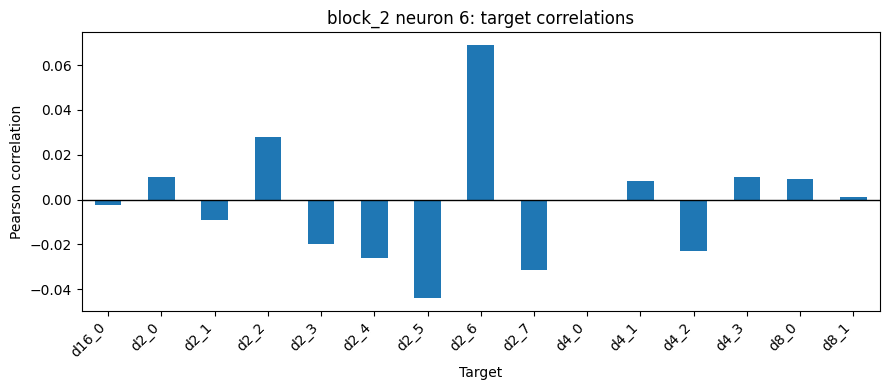

In [ ]:
import matplotlib.pyplot as plt

SELECT_LAYER_IDX = 2
SELECT_NEURON_IDX = 6

if SELECT_LAYER_IDX not in correlation_by_layer:
    raise ValueError(f"SELECT_LAYER_IDX must be one of {list(correlation_by_layer)}")
selected_corr = correlation_by_layer[SELECT_LAYER_IDX]
if SELECT_NEURON_IDX < 0 or SELECT_NEURON_IDX >= selected_corr.shape[0]:
    raise ValueError(f"SELECT_NEURON_IDX must be in [0, {selected_corr.shape[0] - 1}]")

selected_neuron_correlations = pd.DataFrame(
    {
        "target": target_columns,
        "correlation": selected_corr[SELECT_NEURON_IDX].numpy(),
    }
)
selected_neuron_correlations["abs_correlation"] = selected_neuron_correlations["correlation"].abs()
selected_neuron_correlations = selected_neuron_correlations.sort_values(
    "abs_correlation",
    ascending=False,
)

layer_name = "embedding" if SELECT_LAYER_IDX == 0 else f"block_{SELECT_LAYER_IDX}"
print(f"Correlations for {layer_name}, neuron {SELECT_NEURON_IDX}")
display(selected_neuron_correlations)

ax = selected_neuron_correlations.sort_values("target").plot(
    x="target",
    y="correlation",
    kind="bar",
    legend=False,
    figsize=(9, 4),
)
ax.axhline(0.0, color="black", linewidth=1)
ax.set_xlabel("Target")
ax.set_ylabel("Pearson correlation")
ax.set_title(f"{layer_name} neuron {SELECT_NEURON_IDX}: target correlations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## PCA Rank-Reduction Analysis
Set `INTERVENTION_LAYER_IDX`, `KEEP_PCS_MIN`, `KEEP_PCS_MAX`, and `KEEP_PCS_STEP` below. Layer index `0` is the embedded residual stream before the first residual block; later indices are after residual blocks / before the corresponding next block.


Using 100000 saved test samples for PCA analysis
Baseline MSE


,mse_all,mse_d2,mse_d4,mse_d8,mse_d16
0,0.000887,0.000145,0.000221,0.000524,0.01021


PCA rank thresholds


,layer_idx,rank_90,rank_99,num_dimensions
0,0,29,32,256
1,1,31,59,256
2,2,37,79,256


PCA intervention MSE sweep


,intervention_layer,keep_pcs,mse_all,mse_d2,mse_d4,mse_d8,mse_d16
0,1,0,1.651388,1.057045,1.031701,3.865652,4.456356
1,1,1,1.444351,1.043311,1.029859,2.776740,3.645862
2,1,2,1.405492,0.995633,1.037148,2.565899,3.836932
3,1,3,1.373226,0.991143,1.051107,2.489665,3.485479
4,1,4,1.393428,0.975074,1.063825,2.552598,3.740338
...,...,...,...,...,...,...,...
124,1,124,0.004708,0.000162,0.000317,0.002318,0.063423
125,1,125,0.004688,0.000161,0.000316,0.002285,0.063202
126,1,126,0.004645,0.000160,0.000306,0.002032,0.063104
127,1,127,0.004512,0.000159,0.000304,0.001985,0.061226


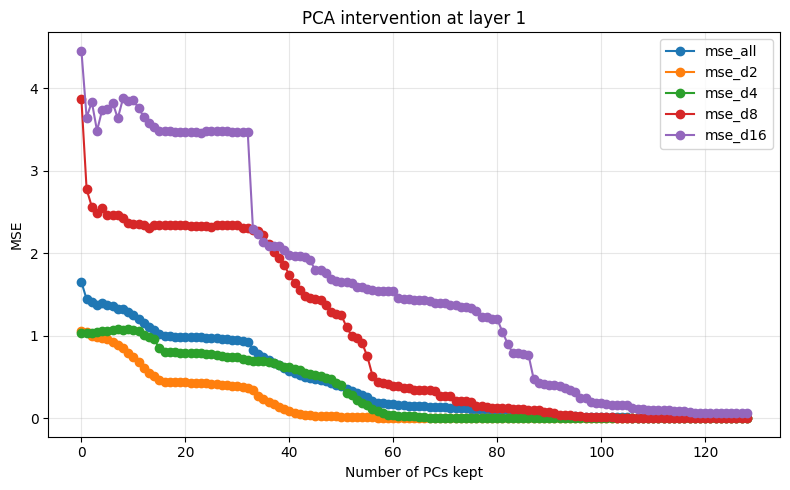

In [ ]:
import matplotlib.pyplot as plt
from parity_net.analysis import (
    collect_layer_activations,
    make_pca_intervention,
    pca_from_activations,
    per_degree_mse,
    predict_in_batches,
    rank_for_threshold,
)

INTERVENTION_LAYER_IDX = 1
KEEP_PCS_MIN = 0
KEEP_PCS_MAX = 128
KEEP_PCS_STEP = 1
PCA_SAMPLES = config["training"]["test_samples"]
ANALYSIS_DIR = Path(DRIVE_RUN_DIR) / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

analysis_config = payload["config"]
analysis_training = analysis_config["training"]
analysis_model_config = analysis_config["model"]
batch_size = analysis_training["batch_size"]

if PCA_SAMPLES is not None and PCA_SAMPLES < test_data.x.shape[0]:
    heldout = ParityDataset(
        x=test_data.x[:PCA_SAMPLES],
        y=test_data.y[:PCA_SAMPLES],
    )
elif PCA_SAMPLES is not None and PCA_SAMPLES > test_data.x.shape[0]:
    raise ValueError(
        f"PCA_SAMPLES={PCA_SAMPLES} exceeds saved test set size={test_data.x.shape[0]}"
    )
else:
    heldout = test_data
print(f"Using {heldout.x.shape[0]} saved test samples for PCA analysis")

model.eval()
with torch.no_grad():
    baseline_pred = predict_in_batches(model, heldout.x, batch_size)
baseline_metrics = per_degree_mse(baseline_pred, heldout.y)
pd.DataFrame([baseline_metrics]).to_csv(ANALYSIS_DIR / "baseline_mse.csv", index=False)
print("Baseline MSE")
display(pd.DataFrame([baseline_metrics]))

activations = collect_layer_activations(model, heldout.x, batch_size)
pcas = [pca_from_activations(layer_acts) for layer_acts in activations]

rank_rows = []
for layer_idx, pca in enumerate(pcas):
    cumulative = pca["cumulative_explained_variance"]
    rank_rows.append(
        {
            "layer_idx": layer_idx,
            "rank_90": rank_for_threshold(cumulative, 0.90),
            "rank_99": rank_for_threshold(cumulative, 0.99),
            "num_dimensions": cumulative.numel(),
        }
    )
rank_df = pd.DataFrame(rank_rows)
rank_df.to_csv(ANALYSIS_DIR / "pca_rank_thresholds.csv", index=False)
print("PCA rank thresholds")
display(rank_df)

if INTERVENTION_LAYER_IDX < 0 or INTERVENTION_LAYER_IDX >= len(pcas):
    raise ValueError(f"INTERVENTION_LAYER_IDX must be in [0, {len(pcas) - 1}]")
if KEEP_PCS_STEP <= 0:
    raise ValueError("KEEP_PCS_STEP must be positive")
if KEEP_PCS_MIN < 0:
    raise ValueError("KEEP_PCS_MIN must be non-negative")
if KEEP_PCS_MAX < KEEP_PCS_MIN:
    raise ValueError("KEEP_PCS_MAX must be at least KEEP_PCS_MIN")

max_available_pcs = pcas[INTERVENTION_LAYER_IDX]["components"].shape[0]
keep_pcs_max_effective = min(KEEP_PCS_MAX, max_available_pcs)
if keep_pcs_max_effective < KEEP_PCS_MAX:
    print(f"Capping KEEP_PCS_MAX at {keep_pcs_max_effective}; only that many PCs are available.")
if KEEP_PCS_MIN > keep_pcs_max_effective:
    raise ValueError(
        f"KEEP_PCS_MIN={KEEP_PCS_MIN} exceeds available PCs={keep_pcs_max_effective} "
        f"at layer {INTERVENTION_LAYER_IDX}"
    )

keep_pcs_values = list(range(KEEP_PCS_MIN, keep_pcs_max_effective + 1, KEEP_PCS_STEP))
if keep_pcs_values[-1] != keep_pcs_max_effective:
    keep_pcs_values.append(keep_pcs_max_effective)

sweep_rows = []
for keep_pcs in keep_pcs_values:
    intervention = make_pca_intervention(pcas[INTERVENTION_LAYER_IDX], keep_pcs)
    with torch.no_grad():
        pred_intervened = predict_in_batches(
            model,
            heldout.x,
            batch_size,
            intervention=(INTERVENTION_LAYER_IDX, intervention),
        )
    sweep_rows.append(
        {
            "intervention_layer": INTERVENTION_LAYER_IDX,
            "keep_pcs": keep_pcs,
            **per_degree_mse(pred_intervened, heldout.y),
        }
    )

pca_sweep_df = pd.DataFrame(sweep_rows)
pca_sweep_df.to_csv(ANALYSIS_DIR / "pca_intervention_mse_sweep.csv", index=False)
print("PCA intervention MSE sweep")
display(pca_sweep_df)

mse_columns = ["mse_all", "mse_d2", "mse_d4", "mse_d8", "mse_d16"]
ax = pca_sweep_df.plot(
    x="keep_pcs",
    y=mse_columns,
    marker="o",
    figsize=(8, 5),
)
ax.set_xlabel("Number of PCs kept")
ax.set_ylabel("MSE")
ax.set_title(f"PCA intervention at layer {INTERVENTION_LAYER_IDX}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "pca_intervention_mse_sweep.png", dpi=150)
plt.show()


## Results
The first table reports how many dimensions recover 90% and 99% of variance at each layer. The second reports MSE after the PCA intervention, including degree 2, 4, 8, and 16 parity groups.



In [ ]:
rank_df = pd.read_csv(Path(ANALYSIS_DIR) / "pca_rank_thresholds.csv")
intervention_df = pd.read_csv(Path(ANALYSIS_DIR) / "pca_intervention_mse.csv")
baseline_df = pd.read_csv(Path(ANALYSIS_DIR) / "baseline_mse.csv")
print("PCA rank thresholds")
display(rank_df)
print("Baseline MSE")
display(baseline_df)
print("PCA intervention MSE")
display(intervention_df[["intervention_layer", "keep_pcs", "mse_d2", "mse_d4", "mse_d8", "mse_d16", "mse_all"]])



PCA rank thresholds


,layer_idx,rank_90,rank_99,num_dimensions
0,0,29,32,512
1,1,31,54,512
2,2,36,59,512
3,3,39,63,512
4,4,40,64,512


Baseline MSE


,mse_all,mse_d2,mse_d4,mse_d8,mse_d16
0,0.000562,0.000422,0.000345,0.001037,0.001596


PCA intervention MSE


,intervention_layer,keep_pcs,mse_d2,mse_d4,mse_d8,mse_d16,mse_all
0,2,50,0.022841,0.012645,0.061798,0.048411,0.027021
